# 01: Data load: raw delivery to tidy store

Turns the 12 delivered Parquet files into `se_interval`: one row per site per 5-minute interval, in the CICCADA convention, partitioned and sorted for querying.

Every conversion happens here, once:

| | |
|---|---|
| **Time** | naive local civil string (with DST) → `ts_utc` → `ts_aest` (fixed UTC+10) |
| **Sign** | reactive power flipped from the load convention to the generator convention |
| **Units** | W → kW, var → kvar (instantaneous, *not* ×12) |
| **Shape** | per-phase columns folded to site level, phase detail kept separately |
| **Layout** | re-partitioned by AEST month, sorted by `(site_alias, ts_utc)` |

## Setup

The build should take roughly 30~45 s per month. 

Peak memory is about the DuckDB limit plus 200 MB, flat across the run, because each month gets its own short-lived connection.

If you are sharing the compute server, set `CICCADA_SE_DUCKDB_MEMORY` and
`CICCADA_SE_DUCKDB_THREADS` before importing. Left unset, DuckDB sizes itself from the
machine. If your raw data sits in OneDrive, consider `CICCADA_SE_STORE_DIR` pointing at
a local scratch disk — the store is ~1.5 GB and rebuilding it would otherwise push the
whole thing through cloud sync each time.

In [1]:
# Reload edited .py modules without restarting the kernel.
# The library carries all the logic, so it gets edited constantly while notebooks
# stay thin -- without this, every module change means a kernel restart and a
# re-run of the expensive cells.
#
# CAVEAT: autoreload rebinds FUNCTIONS, not objects already constructed at import
# time. If you change a dataclass in se_params (SEAnalysisConfig, SEVoltVarParams)
# or a constant in se_config, restart the kernel -- `CONFIG` and `PARAMS` are
# module-level instances and will still be the old ones.
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents)
     if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate the CICCADA repository root from {_current}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from solar_edge.config import se_config as C
from solar_edge.lib import se_store
from solar_edge.lib import se_ingest as ing

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

con = se_store.connect(verbose=True)
print("Store directory:", C.STORE_DIR)

  registered  se_raw               12 monthly Parquet files
  registered  se_alias             alias_mapping_alias_only.csv
  registered  se_interval          partitioned, 24 files, + derived columns
  registered  se_site              single file
  registered  se_site_capacity     single file
Store directory: C:\Users\z3553082\AppData\Local\ciccada\solar_edge_store


## 1. Conventions being applied

In [2]:
display(C.describe_conventions())

,convention,value
0,active power: source convention,"generator (production magnitude, always >= 0)"
1,active power: sign applied,+1 (no change)
2,reactive sign: sites fitting,"213 as-delivered / 106 flipped / 1,271 neither"
3,reactive power: source convention,AS DELIVERED -- majority of curve-following si...
4,reactive power: sign applied,+1 (no change)
5,target convention,generator (AS/NZS 4777.2 Fig 3.2; negative Q =...
6,basis for the reactive sign,"fleet_orientation_fit over all 1,590 assessabl..."
7,active power units,W -> kW
8,reactive power units,var -> kvar (instantaneous; NOT multiplied by 12)
9,raw timestamp frame,"per-site local civil time, INCLUDING daylight ..."


## 2. Daylight-saving hazards in the raw delivery

**NSW and South Australia do observe daylight saving. Queensland does not.** 

The two windows below are hazardous *for NSW and SA*.

**October — clocks go forward.** At 02:00 on 2025-10-05, NSW and SA clocks jump straight
to 03:00. The wall-clock hour 02:00–02:59 **never happens** in those states on that date.
So a NSW or SA row carrying that timestamp could only come from a logger whose clock is
not daylight-saving aware. Left alone, ICU shifts it forward onto 03:00–03:59, where it
collides with a genuine reading — and deduplication would then throw away real data.

**April — clocks go back.** At 03:00 on 2025-04-06, NSW and SA clocks fall back to 02:00.
The wall-clock hour 02:00–02:59 therefore happens **twice**: once on daylight time, then
again an hour later on standard time. Two genuinely different moments wearing the same
label. For Sydney:

| Wall clock | Offset | Actual instant (UTC) |
|---|---|---|
| 02:30 (first pass, AEDT) | UTC+11 | 2025-04-05 15:30 |
| 02:30 (second pass, AEST) | UTC+10 | 2025-04-05 16:30 |

A bare string `2025-04-06 02:30:00` cannot tell you which. A site logging every 5 minutes
through the whole overlap emits 24 rows carrying only 12 distinct timestamps.

**Neither hazard materialises in this delivery.** Zero NSW/SA rows fall in the October
gap, so the site clocks are daylight-saving aware. And every April-overlap row has a
distinct key, so no site logged through both passes. Queensland rows show up in both
windows only because 02:00–03:00 is an entirely ordinary hour there.

`build_month` asserts this per month rather than trusting it — run this against any new
delivery before rebuilding.

In [3]:
display(ing.dst_hazards(con))

,dst_window,state,observes_dst_exempt,n_rows,n_sites,n_distinct_keys,n_repeat_keys
0,"April (clocks back, local 02:00-03:00 occurs t...",New South Wales,False,74,8,74,0
1,"April (clocks back, local 02:00-03:00 occurs t...",Queensland,True,144,12,144,0
2,"April (clocks back, local 02:00-03:00 occurs t...",South Australia,False,227,19,227,0
3,"October (clocks forward, local 02:00-03:00 abs...",Queensland,True,169,15,169,0


## 3. Build the store

One month at a time. `build_store()` refuses to overwrite an existing store unless told to.

Passing `months=[...]` instead appends just those months, which makes an interrupted build resumable rather than a restart.

Each month writes files named for its source, so a month legitimately spills into the
neighbouring AEST partition without clobbering anything. That spillover is expected: a
South Australian midnight in local time is the previous day in the AEST analysis frame.

In [4]:
# Set overwrite=True to rebuild from scratch. To resume after an interruption:
#     ing.build_store(con, months=["2025-07", "2025-08"])
stats = ing.build_store(con, overwrite=True)
display(stats)

print(f"Total rows written: {stats.store_rows.sum():,}")
print(f"Duplicate rows removed: {stats.duplicates_removed.sum():,}")
print(f"UTC collisions (must be 0): {stats.utc_collisions.sum()}")
print(f"Wall time: {stats.seconds.sum() / 60:.1f} min")

  [ 1/12] 2025-01   8,232,270 rows   1542 sites      8 dup    46.6s
  [ 2/12] 2025-02   7,090,693 rows   1548 sites     24 dup    42.5s
  [ 3/12] 2025-03   7,216,969 rows   1542 sites  1,985 dup    41.4s
  [ 4/12] 2025-04   6,619,074 rows   1549 sites     26 dup    35.3s
  [ 5/12] 2025-05   6,438,991 rows   1554 sites     26 dup    38.1s
  [ 6/12] 2025-06   6,074,214 rows   1561 sites     12 dup    32.4s
  [ 7/12] 2025-07   6,422,526 rows   1570 sites     18 dup    33.8s
  [ 8/12] 2025-08   6,783,024 rows   1578 sites     27 dup    35.0s
  [ 9/12] 2025-09   7,059,192 rows   1583 sites     26 dup    37.6s
  [10/12] 2025-10   7,864,691 rows   1587 sites     17 dup    43.7s
  [11/12] 2025-11   8,118,635 rows   1591 sites     21 dup    45.8s
  [12/12] 2025-12   8,720,689 rows   1599 sites     27 dup    49.4s


,source_month,raw_rows,store_rows,duplicates_removed,utc_collisions,n_sites,min_ts_aest,max_ts_aest,seconds
0,2025-01,8232278,8232270,8,0,1542,2024-12-31 23:00:19,2025-01-31 23:59:53,46.6
1,2025-02,7090717,7090693,24,0,1548,2025-01-31 23:00:18,2025-02-28 23:59:52,42.5
2,2025-03,7218954,7216969,1985,0,1542,2025-02-28 23:00:17,2025-03-31 23:59:51,41.4
3,2025-04,6619100,6619074,26,0,1549,2025-03-31 23:00:05,2025-05-01 00:29:59,35.3
4,2025-05,6439017,6438991,26,0,1554,2025-05-01 00:00:04,2025-06-01 00:29:55,38.1
5,2025-06,6074226,6074214,12,0,1561,2025-06-01 00:00:05,2025-07-01 00:29:59,32.4
6,2025-07,6422544,6422526,18,0,1570,2025-07-01 00:00:17,2025-08-01 00:29:59,33.8
7,2025-08,6783051,6783024,27,0,1578,2025-08-01 00:00:03,2025-09-01 00:29:59,35.0
8,2025-09,7059218,7059192,26,0,1583,2025-09-01 00:00:04,2025-10-01 00:29:33,37.6
9,2025-10,7864708,7864691,17,0,1587,2025-10-01 00:00:04,2025-10-31 23:59:52,43.7


Total rows written: 86,640,968
Duplicate rows removed: 2,217
UTC collisions (must be 0): 0
Wall time: 8.0 min


## 4. Reconciliation

Five claims, each checked against the **deduplicated** raw basis — comparing against raw
totals that still contain duplicates would always show a spurious mismatch.

1. **Rows accounted for** — an identity, not a tolerance: store rows equal raw distinct
   `(site, timestamp)` keys.
2. **Conflicting duplicates** — reported, not asserted (see section 6).
3. **Sites conserved** — 1,602 in both.
4. **Active energy conserved** — exercises the phase folding and the W→kW conversion.
5. **Reactive energy sign-flipped** — the store total must equal −1 × the raw total. This
   is the sign correction stated as a testable claim rather than a comment.

In [4]:
recon = ing.reconcile(con)
display(recon)

assert recon["pass"].all(), "Reconciliation failed — do not proceed to D4."
print("Reconciliation PASSED.")

,check,raw,store,delta,pass
0,rows accounted for (deduplicated basis),"86,640,968 distinct keys","86,640,968","2,217 duplicate rows removed from 86,643,185",True
1,duplicate keys with conflicting values (inform...,"2,217 duplicate rows",-,"1,101 conflicting keys -- see night_generation...",True
2,sites conserved,"1,602","1,602",0,True
3,active energy conserved (kW-sum),"205,425,571.846","205,425,581.604",relative 4.75e-08,True
4,reactive energy unchanged (as delivered) (kvar...,"-4,027,765.219","-4,027,765.603",relative 9.52e-08 vs +1 x raw,True


Reconciliation PASSED.


## 5. Did the timezone resolution work?

The fleet-wide diurnal profile in the AEST analysis frame is the acceptance test. It
should peak at hour 12 and fall to near zero overnight, with no double-humping or
smearing — which is what you would see if the three states had been pooled in
mismatched frames.

Peak hour: 12  (expected 12)


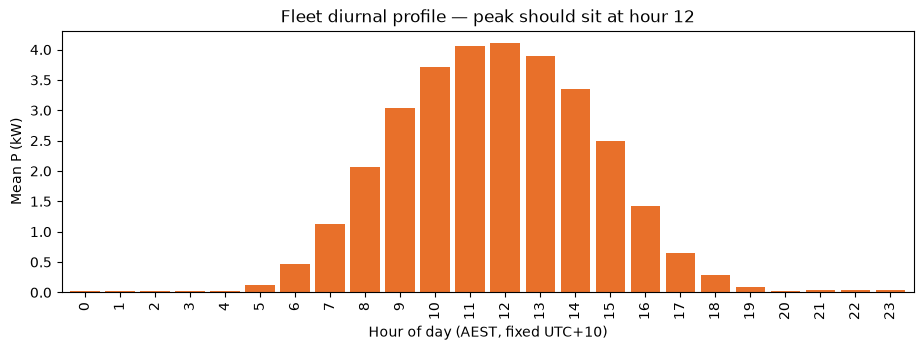

In [5]:
profile = se_store.q(con, """
    SELECT hour(ts_aest) AS hour_aest,
           count(*)                  AS n_rows,
           round(avg(P_kW), 3)       AS mean_P_kW
    FROM se_interval
    GROUP BY 1 ORDER BY 1
""")

ax = profile.plot(x="hour_aest", y="mean_P_kW", kind="bar", figsize=(11, 3.4),
                  legend=False, color="#e8702a", width=0.85)
ax.set_xlabel("Hour of day (AEST, fixed UTC+10)")
ax.set_ylabel("Mean P (kW)")
ax.set_title("Fleet diurnal profile — peak should sit at hour 12")
peak = int(profile.loc[profile.mean_P_kW.idxmax(), "hour_aest"])
print(f"Peak hour: {peak}  (expected 12)")

### Per-state check

The stronger test. Each state was converted through its own IANA zone, so if that worked
the power-weighted centroids should land on each city's true solar noon expressed in
AEST — Brisbane earliest, then Sydney, then Adelaide about 50 minutes later.

The seasonal comparison is what proves DST was handled: Queensland must barely move
between June and January, while NSW and SA must not shift by a whole hour. If daylight
saving had been ignored, they would.

In [6]:
centroids = se_store.q(con, """
    SELECT state,
           CASE WHEN month(ts_aest) = 6 THEN 'June' ELSE 'January' END AS season,
           round(sum((hour(ts_aest) * 60 + minute(ts_aest)) * greatest(P_kW, 0))
                 / nullif(sum(greatest(P_kW, 0)), 0) / 60.0, 3) AS centroid_hour_aest
    FROM se_interval
    WHERE month(ts_aest) IN (1, 6)
    GROUP BY 1, 2 ORDER BY 1, 2
""")
display(centroids.pivot(index="state", columns="season", values="centroid_hour_aest"))

season,January,June
state,,
New South Wales,12.065,11.914
Queensland,11.960,11.786
South Australia,12.976,12.798


## 6. Sites generating outside daylight hours

### Likely storage (5 sites, ~92% of the affected rows)

These inverters report **continuously**: ~105,000 rows a year, which is exactly
24 h × 12 intervals × 365, with overnight row counts matching midday row counts. Their
night output is a low, flat plateau that scales with season — AUS639 averages 0.46 kW
overnight in January and 0.10 kW in June, flat right across the night rather than
peaking anywhere.

### Stray timestamps (15 sites, ~8% of the affected rows)

These report daylight hours only (~53,000 rows a year) and carry a handful of night rows
— 3 to 323 across the whole year — at daytime power levels. This is the original
hypothesis, and for these sites it holds.

In [7]:
anomaly = ing.night_generation_anomaly(con)
display(anomaly)

summary = anomaly.groupby("classification").agg(
    sites=("site_alias", "count"), night_rows=("n_night_rows", "sum"))
display(summary)

print("night_coverage_pct is the discriminator: overnight rows as a % of midday rows.")
print("~100% means the inverter logs all night (storage); ~0% means daylight-only.")
print("Sites near the 50% boundary are genuinely ambiguous - check them individually.")

anomaly.to_csv(C.ARTEFACT_DIR / "night_generation_sites.csv", index=False)
print(f"\nWritten to {C.ARTEFACT_DIR / 'night_generation_sites.csv'}")

,site_alias,state,n_rows,n_night_rows,night_coverage_pct,max_night_P_kW,mean_deep_night_P_kW,mean_midday_P_kW,classification
0,AUS639,South Australia,105291,11828,99.7,4.92,0.262,2.458,likely_storage
1,AUS384,South Australia,105410,3470,100.0,4.89,0.149,3.555,likely_storage
2,AUS958,New South Wales,103218,2069,94.6,3.66,0.202,4.782,likely_storage
3,AUS1283,Queensland,105130,1669,99.9,4.92,0.181,4.785,likely_storage
4,AUS830,South Australia,103898,1411,100.3,4.91,0.253,3.054,likely_storage
5,AUS908,New South Wales,77009,596,46.3,4.91,0.165,2.520,stray_timestamps
6,AUS1183,South Australia,53697,323,1.4,3.46,1.133,2.083,stray_timestamps
7,AUS244,South Australia,53753,254,1.1,3.38,1.115,2.148,stray_timestamps
8,AUS052,Queensland,53004,74,0.3,8.00,1.816,4.575,stray_timestamps
9,AUS604,South Australia,55503,63,0.3,4.95,0.842,3.607,stray_timestamps


,sites,night_rows
classification,,
likely_storage,5,20447
stray_timestamps,15,1677


night_coverage_pct is the discriminator: overnight rows as a % of midday rows.
~100% means the inverter logs all night (storage); ~0% means daylight-only.
Sites near the 50% boundary are genuinely ambiguous - check them individually.

Written to C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\night_generation_sites.csv


## 7. Where the daylight-saving rows landed

A confirmation step for section 2, and the one piece of this notebook that needs its
frame stated carefully.

The transition is an **instant**, not a wall-clock hour, so this filters on `ts_utc`, not
`ts_aest`. The two DST changeovers occur at:

| Transition | UTC instant |
|---|---|
| April, clocks back (03:00 AEDT → 02:00 AEST) | 2025-04-05 16:00 |
| October, clocks forward (02:00 AEST → 03:00 AEDT) | 2025-10-04 16:00 |

The query takes a two-hour UTC window straddling each, and counts what landed there by
state. It is asking: *after conversion, did anything strange end up near the boundary?*

What to expect, and what the output shows: a handful of rows and essentially no
generation, because this is 02:00–03:00 local — inside the ~3% overnight coverage.
Queensland appears because it shares the UTC window, not because anything happened to it.

This overlaps deliberately with `dst_hazards()` in section 2. That one checks the **raw**
delivery *before* conversion; this checks the **store** *after*. Same question from both
ends — the check that matters most is section 2, since that is the one that can fail.

In [8]:
display(ing.dst_audit(con))

,boundary,state,n_rows,max_P_kW,first_ts_utc,last_ts_utc
0,April (clocks back; local 02:00-03:00 repeats),New South Wales,74,0.421,2025-04-05 16:00:17,2025-04-05 16:59:32
1,April (clocks back; local 02:00-03:00 repeats),Queensland,288,0.282,2025-04-05 15:00:08,2025-04-05 16:59:51
2,April (clocks back; local 02:00-03:00 repeats),South Australia,221,0.596,2025-04-05 15:00:01,2025-04-05 16:59:57
3,October (clocks forward; local 02:00-03:00 ski...,New South Wales,168,0.240,2025-10-04 15:00:17,2025-10-04 16:59:14
4,October (clocks forward; local 02:00-03:00 ski...,Queensland,337,0.241,2025-10-04 15:00:09,2025-10-04 16:59:51
5,October (clocks forward; local 02:00-03:00 ski...,South Australia,364,0.809,2025-10-04 15:00:01,2025-10-04 16:59:11


## 8. Re-partitioning

The delivered files have a single row group each, so any predicate forces a full column
scan. The store is sorted by `(site_alias, ts_utc)` within month partitions, which is
what lets DuckDB skip row groups.

The single-site query is the one to watch — that access pattern drives every per-site
diagnostic and day plot from here on.

In [9]:
import time

def timed(label, sql):
    start = time.perf_counter()
    n = con.execute(sql).fetchone()[0]
    return {"query": label, "seconds": round(time.perf_counter() - start, 3), "rows": n}

raw_files = C.duckdb_path_list(C.raw_files())
bench = pd.DataFrame([
    timed("RAW  : one site, whole year",
          f"SELECT count(*) FROM read_parquet({raw_files}) WHERE site_alias='AUS765'"),
    timed("STORE: one site, whole year",
          "SELECT count(*) FROM se_interval WHERE site_alias='AUS765'"),
    timed("STORE: one site, one month",
          "SELECT count(*) FROM se_interval WHERE site_alias='AUS765' AND dt_month='2025-06'"),
    timed("STORE: Volt-VAr band, whole year",
          "SELECT count(*) FROM se_interval "
          "WHERE V_max > 240 AND V_max < 253 AND hour(ts_aest) BETWEEN 11 AND 13"),
])
display(bench)
display(se_store.store_status(con)[["logical_name", "exists", "size_mb", "n_rows"]])

,query,seconds,rows
0,"RAW : one site, whole year",0.027,54832
1,"STORE: one site, whole year",0.019,54832
2,"STORE: one site, one month",0.012,3981
3,"STORE: Volt-VAr band, whole year",0.492,16795496


,logical_name,exists,size_mb,n_rows
0,se_interval,True,1469.9,86640968.0
1,se_interval_phase,False,NaN,NaN
2,se_site,True,0.0,1602.0
3,se_site_capacity,True,0.1,1600.0
4,bom_solar,False,NaN,NaN
5,se_structured,False,NaN,NaN
6,se_ghi_model,False,NaN,NaN
7,se_uncurtailedpv,False,NaN,NaN
8,se_conformance_voltvar,False,NaN,NaN
9,se_conformance_voltwatt,False,NaN,NaN
